# F-test distribution
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import f

### (1) Define F-test experiment

Use standard normal distribution ($\mu=0$, $\sigma=1$) for simplicity


In [2]:
# Generate multiple measurements in one call 

def mychi(npt,ngen=1):
    mes = np.random.normal(size=(ngen,npt))
    return np.sum(mes*mes, axis=1)
    
def myFtest(n1,n2,ngen=1):
    ch1 = mychi(n1,ngen)/n1
    ch2 = mychi(n2,ngen)/n2
    return ch1/ch2

### (2) Run multiple experiments

In [3]:
# Number of measurement sequences

Ntry = 100000

# Number of measurements in two sequences

N1 = 1
N2 = 20

# Generate multiple measurements in one call

fval = myFtest(N1,N2,Ntry)

### (3) Plot results

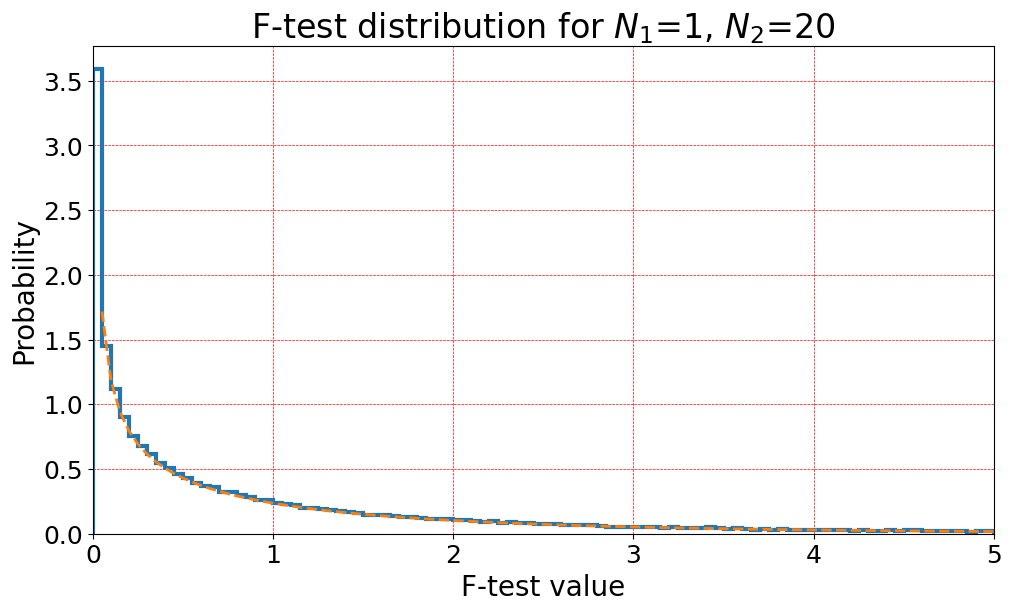

In [4]:
# Range for result histogram

Xmax=5.
Nbin = 100

# Plot histogram

plt.figure(figsize=(10, 6),layout='constrained')

plt.hist(fval,bins=Nbin, range=[0,Xmax], density=True, log=False, histtype='step',linewidth=3)

plt.xlabel('F-test value',size=20)
plt.ylabel('Probability',size=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('F-test distribution for $N_{1}$='+str(N1)+', $N_{2}$='+str(N2),size=24)
plt.xlim([0,Xmax])
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

# Expected distribution

x_tab = np.linspace(0.,Xmax,Nbin+1)
y_tab = f.pdf(x_tab,N1,N2)
plt.plot(x_tab,y_tab,'--',linewidth=2)

fname = '09_F-test_'+str(N1)+'_'+str(N2)+'.png'
plt.savefig(fname)

plt.show()

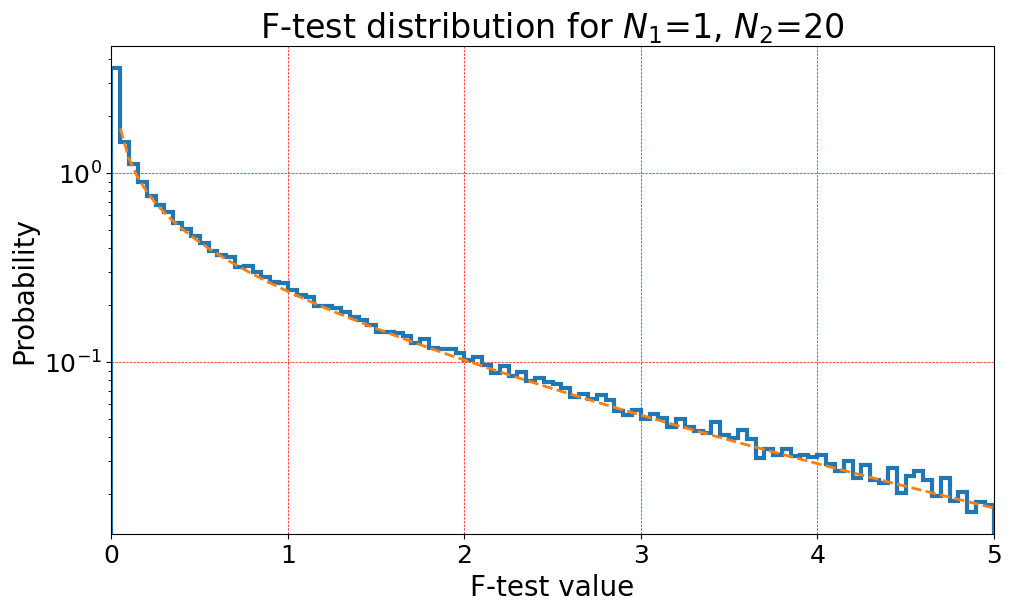

In [5]:
# Same plot in log scale

plt.figure(figsize=(10, 6),layout='constrained')

plt.hist(fval,bins=Nbin, range=[0,Xmax], density=True, log=True, histtype='step',linewidth=3)

plt.xlabel('F-test value',size=20)
plt.ylabel('Probability',size=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('F-test distribution for $N_{1}$='+str(N1)+', $N_{2}$='+str(N2),size=24)
plt.xlim([0,Xmax])
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

# Expected distribution

x_tab = np.linspace(0.,Xmax,Nbin+1)
y_tab = f.pdf(x_tab,N1,N2)
plt.plot(x_tab,y_tab,'--',linewidth=2)

fname = '09_F-test_'+str(N1)+'_'+str(N2)+'_log.png'
plt.savefig(fname)

plt.show()